# 02 — Nocca-Nocca: Minimax y MCTS

**Obligatorio 2 — Sistemas Multiagente**

Nocca-Nocca es un juego de tablero de **información perfecta**, 2 jugadores
(Black / White), con un espacio de estados **mucho mayor** que Tic-Tac-Toe:
**320 acciones** posibles, las piezas se apilan y hay que llevar una pieza a la
fila meta del rival. Las partidas son **largas** (~90-100 jugadas).

Esto cambia por completo el análisis respecto a Tic-Tac-Toe:

- La búsqueda exhaustiva es **inviable**: minimax corre solo a profundidad baja
  apoyándose en la **función de evaluación** `NoccaNocca.eval` (progreso hacia la
  meta + control de pilas + movilidad).
- MCTS no necesita heurística, pero con tantas acciones y partidas tan largas
  **cada decisión es costosa** y el *rollout* aleatorio aporta menos señal.

> **Costo computacional (clave en este juego).** En la corrida de referencia
> (`max_steps=40`): `Minimax(d1) ≈ 0.7 s/partida`, **`Minimax(d2) ≈ 13 s/partida`**
> (~20× más caro), `MCTS(10) ≈ 2.5 s/partida`, `MCTS(25) ≈ 9 s/partida`. Por eso
> usamos pocos juegos por configuración (`NG`) y acotamos `max_steps`. Recompensas:
> `+1` gana, `0` empate/truncado, `-1` pierde.

In [1]:
import sys, os
try:
    ROOT = os.path.dirname(__vsc_ipynb_file__)   # VS Code
except NameError:
    ROOT = os.getcwd()                            # Jupyter / fallback
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Raiz del proyecto:", ROOT)

Raiz del proyecto: C:\Users\joaco\Documents\ort\semestre_3\obligatorio2-sma\obligatorio_2_joaco


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

from games.nocca_nocca.nocca_nocca import NoccaNocca
from agents.minimax import MiniMax
from agents.mcts import MonteCarloTreeSearch
from agents.agent_random import RandomAgent
from utils import matchup_both_sides

np.random.seed(42)
MAX_STEPS = 40     # cota de pasos por partida (juegos cortos para que sea manejable)
NG = 10            # partidas por posicion (se juegan ambas => 2*NG; subir si hay tiempo)
nocca = lambda: NoccaNocca(max_steps=MAX_STEPS)
R = lambda g, a: RandomAgent(g, a)
print("Acciones:", nocca().n_actions, "| MAX_STEPS:", MAX_STEPS, "| NG:", NG)

Acciones: 320 | MAX_STEPS: 40 | NG: 10


## 1. Agentes vs Random: desempeño y costo

Comparamos en una sola pasada cada agente contra Random (jugando ambas posiciones).
Cada configuración se evalúa **una única vez** porque son experimentos caros.

In [3]:
contendientes = {
    'Random':      lambda g, a: RandomAgent(g, a),
    'Minimax(d1)': lambda g, a: MiniMax(g, a, depth=1),
    'Minimax(d2)': lambda g, a: MiniMax(g, a, depth=2),
    'MCTS(10)':    lambda g, a: MonteCarloTreeSearch(g, a, simulations=10, rollouts=1),
    'MCTS(25)':    lambda g, a: MonteCarloTreeSearch(g, a, simulations=25, rollouts=1),
}
rows = []
for name, mk in contendientes.items():
    res = matchup_both_sides(nocca, make_a=mk, make_b=R, n_games=NG)
    rows.append({'agente': name, 'mean_reward': res['mean_reward_A'],
                 'win':  (res['as_p0']['win']  + res['as_p1']['win'])  / 2,
                 'draw': (res['as_p0']['draw'] + res['as_p1']['draw']) / 2,
                 'loss': (res['as_p0']['loss'] + res['as_p1']['loss']) / 2,
                 'time_per_game': res['time'] / (2 * NG)})
    print(f"  {name:12s} reward={rows[-1]['mean_reward']:+.2f}  t/partida={rows[-1]['time_per_game']:.1f}s")
df_base = pd.DataFrame(rows)
df_base.round(3)

  Random       reward=-0.05  t/partida=0.1s


  Minimax(d1)  reward=+0.85  t/partida=1.0s


  Minimax(d2)  reward=+1.00  t/partida=21.8s


  MCTS(10)     reward=+0.50  t/partida=4.4s


  MCTS(25)     reward=+0.50  t/partida=11.1s


,agente,mean_reward,win,draw,loss,time_per_game
0,Random,-0.05,0.00,0.95,0.05,0.051
1,Minimax(d1),0.85,0.85,0.15,0.00,0.975
2,Minimax(d2),1.00,1.00,0.00,0.00,21.784
3,MCTS(10),0.50,0.50,0.50,0.00,4.428
4,MCTS(25),0.50,0.50,0.50,0.00,11.052


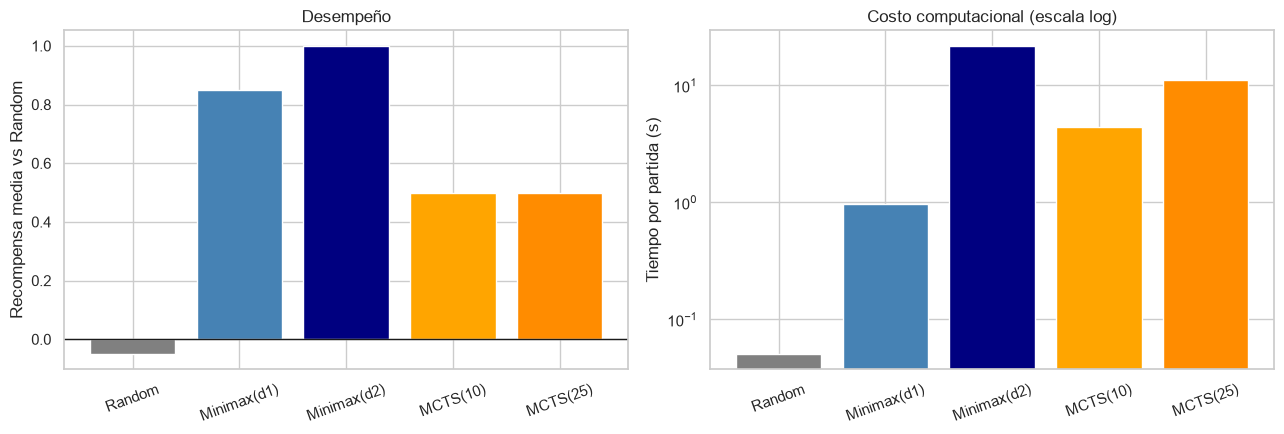

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
colors = ['gray', 'steelblue', 'navy', 'orange', 'darkorange']
ax[0].bar(df_base.agente, df_base.mean_reward, color=colors)
ax[0].axhline(0, color='k', lw=1)
ax[0].set(ylabel='Recompensa media vs Random', title='Desempeño'); ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(df_base.agente, df_base.time_per_game, color=colors)
ax[1].set(ylabel='Tiempo por partida (s)', title='Costo computacional (escala log)'); ax[1].set_yscale('log')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Lectura.** Con la función de evaluación, **Minimax vence a Random con holgura ya
con profundidad 1** y a bajo costo; subir a `d=2` multiplica el tiempo ~20× sin
mejorar el resultado frente a un rival tan débil (mismo reward, mucho más caro).
**MCTS también supera a Random**, aunque con menor margen y con fuerte dependencia
de la posición y del presupuesto de simulaciones: frente a 320 acciones y partidas
largas, parte de las manos terminan en empate por truncamiento.

## 2. Enfrentamiento directo y efecto de la posición

Minimax(d1) contra MCTS(25), jugando ambas posiciones (Black abre).

In [5]:
res = matchup_both_sides(nocca,
    make_a=lambda g, a: MiniMax(g, a, depth=1),
    make_b=lambda g, a: MonteCarloTreeSearch(g, a, simulations=25, rollouts=1),
    n_games=NG)
print("Minimax(d1) vs MCTS(25):")
print("  reward medio de Minimax (ambas posiciones):", round(res['mean_reward_A'], 2))
print("  como Black (abre):", round(res['mean_p0'], 2), "| como White:", round(res['mean_p1'], 2))

Minimax(d1) vs MCTS(25):
  reward medio de Minimax (ambas posiciones): 0.35
  como Black (abre): 0.5 | como White: 0.2


## 3. Funciones de evaluación: comparación

La letra pide variar también las **funciones de evaluación**. La `eval` de
`NoccaNocca` es **agregada**: combina tres componentes —progreso hacia la meta
(0.5), control de pilas (0.25) y movilidad (0.25)—. Comparamos tres heurísticas
para `MiniMax(d=1)`:

- **completa** — la `eval` agregada original.
- **progreso** — solo la distancia de las piezas a la fila meta.
- **movilidad** — solo la cantidad de movimientos legales disponibles.

Para poder enfrentar dos heurísticas distintas **en la misma partida**, inyectamos
la función de evaluación en el **agente** (`MiniMaxEval`) en lugar de usar
`game.eval` (que es común a ambos jugadores). Hacemos dos lecturas:

1. **(a) vs Random** — *sanity check* de cada heurística contra un rival débil.
2. **(b) duelos directos** entre heurísticas — para ver cuál produce mejor juego.

Como el **progreso** es la componente de mayor peso (0.5) dentro de la `eval`
agregada, esperamos que **progreso** y **completa** queden parejas y claramente por
encima de la **movilidad** sola, que está poco alineada con el objetivo (llegar a
la meta). *(Con pocos juegos por partida los duelos tienen varianza apreciable; lo
robusto es el orden relativo, no el valor exacto.)*

In [6]:
# Para comparar funciones de evaluacion necesitamos atar la heuristica al AGENTE
# (no al juego: game.eval es comun a ambos jugadores). Asi dos minimax pueden usar
# heuristicas DISTINTAS en la misma partida y enfrentarse directamente.
from games.nocca_nocca.board import BLACK, WHITE, BLACK_GOAL, WHITE_GOAL, BLACK_START
_GOAL = {BLACK: BLACK_GOAL, WHITE: WHITE_GOAL}
_MAXD = abs(BLACK_GOAL - BLACK_START)   # = 6

def eval_completa(game, agent):
    return game.eval(agent)             # heuristica AGREGADA original (progreso+control+movilidad)

def eval_progreso(game, agent):         # solo distancia de las piezas a la meta
    if game.terminated():
        return game.rewards[agent]
    p = game.agent_name_mapping[agent]; o = 1 - p
    def prog(pl):
        pieces = np.argwhere(game.board.squares == pl)
        if len(pieces) == 0:
            return -1.0
        return sum(1.0 - abs(x - _GOAL[pl]) / _MAXD for x, y, k in pieces) / 5.0
    return max(-1.0, min(1.0, prog(p) - prog(o)))

def eval_movilidad(game, agent):        # solo cantidad de movimientos legales
    if game.terminated():
        return game.rewards[agent]
    p = game.agent_name_mapping[agent]; o = 1 - p
    mp = min(len(game.board.legal_moves(p)) / 20.0, 1.0)
    mo = min(len(game.board.legal_moves(o)) / 20.0, 1.0)
    return max(-1.0, min(1.0, mp - mo))

class MiniMaxEval(MiniMax):
    """Minimax con funcion de evaluacion inyectada en el agente (en vez de game.eval)."""
    def __init__(self, game, agent, eval_fn, depth=1, seed=None):
        super().__init__(game, agent, seed=seed, depth=depth)
        self.eval_fn = eval_fn
    def eval(self, game):
        return self.eval_fn(game, self.agent)

EVALS = {'completa': eval_completa, 'progreso': eval_progreso, 'movilidad': eval_movilidad}
NG_EVAL = 6   # partidas por posicion (2*NG_EVAL por matchup); subir reduce varianza

# (a) Sanity vs Random: ante un rival debil, las heuristicas utiles deberian ganar.
base = []
for name, fn in EVALS.items():
    res = matchup_both_sides(nocca,
        make_a=lambda g, a, fn=fn: MiniMaxEval(g, a, fn, depth=1),
        make_b=R, n_games=NG_EVAL)
    base.append({'eval': name, 'reward_vs_random': res['mean_reward_A']})
df_evalR = pd.DataFrame(base)
print("(a) vs Random:")
print(df_evalR.round(3).to_string(index=False))

# (b) Duelos directos entre heuristicas (misma partida, distinta eval por agente).
#     Aqui se ve cual heuristica produce mejor juego.
duelos = [('completa', 'movilidad'), ('progreso', 'movilidad'), ('completa', 'progreso')]
rows = []
for a, b in duelos:
    res = matchup_both_sides(nocca,
        make_a=lambda g, ag, a=a: MiniMaxEval(g, ag, EVALS[a], depth=1),
        make_b=lambda g, ag, b=b: MiniMaxEval(g, ag, EVALS[b], depth=1),
        n_games=NG_EVAL)
    rows.append({'duelo': f'{a} vs {b}', 'reward_primero': res['mean_reward_A']})
    print(f"  {a:9s} vs {b:9s}: reward({a})={res['mean_reward_A']:+.2f}")
df_duel = pd.DataFrame(rows)
df_duel.round(3)

(a) vs Random:
     eval  reward_vs_random
 completa             0.833
 progreso             1.000
movilidad             0.000


  completa  vs movilidad: reward(completa)=+0.75


  progreso  vs movilidad: reward(progreso)=+0.50


  completa  vs progreso : reward(completa)=+0.33


,duelo,reward_primero
0,completa vs movilidad,0.750
1,progreso vs movilidad,0.500
2,completa vs progreso,0.333


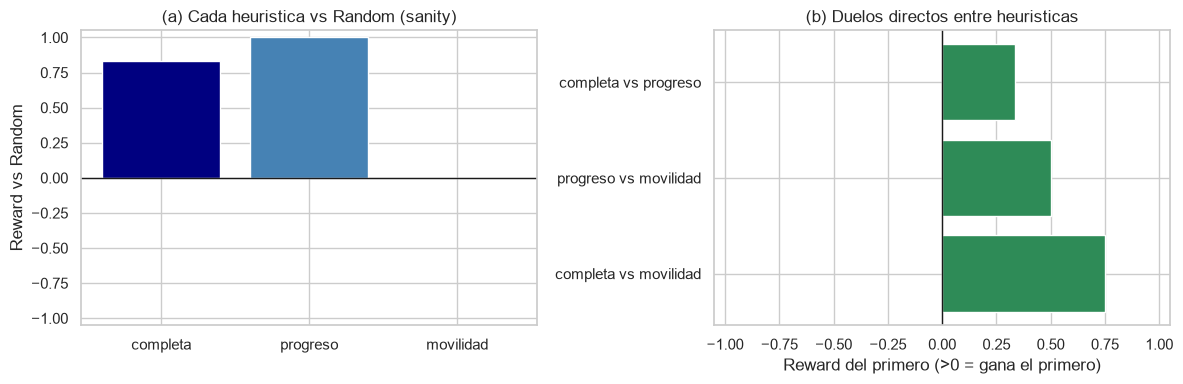

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(df_evalR['eval'], df_evalR['reward_vs_random'],
          color=['navy', 'steelblue', 'lightblue'])
ax[0].axhline(0, color='k', lw=1)
ax[0].set(ylabel='Reward vs Random', title='(a) Cada heuristica vs Random (sanity)')
ax[0].set_ylim(-1.05, 1.05)
colors = ['seagreen' if v >= 0 else 'crimson' for v in df_duel['reward_primero']]
ax[1].barh(df_duel['duelo'], df_duel['reward_primero'], color=colors)
ax[1].axvline(0, color='k', lw=1)
ax[1].set(xlabel='Reward del primero (>0 = gana el primero)',
          title='(b) Duelos directos entre heuristicas', xlim=(-1.05, 1.05))
plt.tight_layout(); plt.show()

## Conclusiones — Nocca-Nocca

- En un juego **grande y de horizonte largo**, la **función de evaluación es
  imprescindible**: minimax no alcanza estados terminales a profundidad baja y, aun
  así, con `d=1` ya vence a Random a muy bajo costo.
- El **costo de minimax crece fuertemente con la profundidad** (`d1 ≈ 0.7 s` vs
  `d2 ≈ 13 s` por partida): sin poda alfa-beta y clonando el tablero en cada nodo,
  las profundidades mayores son impracticables.
- **MCTS es competitivo pero más caro por unidad de fuerza**: vence a Random y en el
  duelo directo `MCTS(25)` puede superar a `Minimax(d1)`. Su desempeño depende mucho
  del número de simulaciones y de la posición, y necesita presupuestos mayores para
  destacar como en Tic-Tac-Toe.
- **La composición de la función de evaluación importa** (sección 3): la **movilidad
  por sí sola** es la heurística más floja —obtiene el reward más bajo contra Random
  y no gana ningún duelo directo—, mientras que **progreso** y la **agregada** son
  claramente superiores y quedan **parejas entre sí**. Es lo esperable: el *progreso
  hacia la meta* es la componente de mayor peso (0.5) de la `eval` y la señal
  alineada con el objetivo del juego. Conclusión de diseño: lo que guía a minimax es
  el progreso; la movilidad aporta como **complemento** dentro de la heurística
  combinada, no como criterio único. *(Con pocas partidas por matchup los valores
  exactos tienen varianza; lo estable entre corridas es este orden relativo.)*
- El eje del análisis vuelve a ser el **compromiso entre presupuesto de cómputo y
  calidad de juego**, mucho más severo que en Tic-Tac-Toe.